# SAE-XCrash — NB03: Probability Calibration
**Work Package WP3** | Target: *Accident Analysis & Prevention* (Q1, Elsevier)

---
### Steps
| # | Description | Output |
|---|-------------|--------|
| 1 | Environment setup & Drive mount | Paths, imports |
| 2 | Load NB02 scores + sanity check | DataFrames, label verification |
| 3 | Pre-calibration ECE/Brier (all models) | Table 3 — ECE uncal column |
| 4 | Fit calibrators on val set | Isotonic + Platt per model |
| 5 | Post-calibration ECE/Brier on test set | Table 3 — ECE cal + Brier columns |
| 6 | Reliability diagrams — LightGBM | Fig 2 (300 dpi) |
| 7 | Reliability diagrams — all models | Fig S1 supplementary (300 dpi) |
| 8 | Operational threshold selection | Val F1-max threshold; cost-utility |
| 9 | Feature group ablations — LightGBM | Table 4 |
| 10 | Save calibrated scores for NB04 | 2 parquet files |
| 11 | WP3 summary report | Console report + calibration log JSON |

**Inputs:** `data/scores/usa_val_scores_uncal.parquet` + `usa_test_scores_uncal.parquet`  
**Rule:** Calibrators are fit on val set ONLY. Test set is used once per model for final ECE/Brier.  
**Seed:** `SEED = 42`

---
## Step 1 — Environment Setup

In [8]:
!pip install -q scikit-learn pyarrow lightgbm

import os, sys, json, warnings, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    brier_score_loss, f1_score,
    balanced_accuracy_score, precision_recall_curve
)
import pickle

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
np.random.seed(SEED)

DPI       = 300
FIG_W     = 14
FIG_H     = 6
TITLE_FS  = 16
LABEL_FS  = 14
TICK_FS   = 12
LEGEND_FS = 12

matplotlib.rcParams.update({
    'figure.dpi'       : DPI,
    'savefig.dpi'      : DPI,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : TITLE_FS,
    'axes.labelsize'   : LABEL_FS,
    'xtick.labelsize'  : TICK_FS,
    'ytick.labelsize'  : TICK_FS,
    'legend.fontsize'  : LEGEND_FS,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'grid.linestyle'   : '--',
})

PALETTE = {
    'lr'       : '#7F8C8D',
    'rf'       : '#2980B9',
    'xgb'      : '#E67E22',
    'lgbm'     : '#27AE60',
    'mlp'      : '#8E44AD',
    'uncal'    : '#C0392B',
    'isotonic' : '#27AE60',
    'platt'    : '#2980B9',
    'perfect'  : '#2C3E50',
    'highlight': '#F39C12',
}

N_BINS = 15   # ECE bin count — fixed throughout (paper §4.4)

# ── ECE helper ────────────────────────────────────────────────────────────────
def ece_score(y_true, y_prob, n_bins=N_BINS):
    """Expected Calibration Error: weighted mean |mean_prob - frac_pos| per bin."""
    bins   = np.linspace(0, 1, n_bins + 1)
    ece    = 0.0
    n      = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        frac_pos  = y_true[mask].mean()
        mean_prob = y_prob[mask].mean()
        ece += mask.sum() / n * abs(mean_prob - frac_pos)
    return round(float(ece), 6)

# ── Full metrics helper ───────────────────────────────────────────────────────
def all_metrics(y_true, y_prob, label=''):
    """Return dict with discrimination + calibration metrics."""
    return {
        'label'   : label,
        'AUROC'   : round(roc_auc_score(y_true, y_prob), 4),
        'AUPRC'   : round(average_precision_score(y_true, y_prob), 4),
        'Bal_Acc' : round(balanced_accuracy_score(y_true, (y_prob >= 0.5).astype(int)), 4),
        'Macro_F1': round(f1_score(y_true, (y_prob >= 0.5).astype(int),
                                   average='macro', zero_division=0), 4),
        'ECE'     : ece_score(y_true, y_prob),
        'Brier'   : round(brier_score_loss(y_true, y_prob), 6),
    }

# ── Bootstrap CI (AUPRC) ─────────────────────────────────────────────────────
def bootstrap_auprc(y_true, y_prob, n=1000):
    rng = np.random.default_rng(SEED)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        try:
            scores.append(average_precision_score(y_true[idx], y_prob[idx]))
        except Exception:
            pass
    scores = np.array(scores)
    return float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

print(f'Python {sys.version}')
print(f'NumPy {np.__version__}  |  Pandas {pd.__version__}')
print('Environment ready ✓')

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy 2.0.2  |  Pandas 2.2.2
Environment ready ✓


In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE       = Path('/content/drive/My Drive/SAE-XCrash')
PROC_DIR   = BASE / 'data' / 'processed'
SCORES_DIR = BASE / 'data' / 'scores'
MODELS_DIR = BASE / 'models' / 'wp2'
CAL_DIR    = BASE / 'models' / 'calibrators'
FIGS_DIR   = BASE / 'figures' / 'wp3_v2'
LOGS_DIR   = BASE / 'logs'

for d in [CAL_DIR, FIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories:')
for d in [SCORES_DIR, PROC_DIR, MODELS_DIR, CAL_DIR, FIGS_DIR, LOGS_DIR]:
    status = 'OK' if d.exists() else 'MISSING'
    print(f'  {d.name:20s}  {status}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directories:
  scores                OK
  processed             OK
  wp2                   OK
  calibrators           OK
  wp3_v2                OK
  logs                  OK


---
## Step 2 — Load NB02 Scores + Sanity Check
Verify label distributions and class balance before any calibration work.

In [10]:
print('Loading NB02 score parquets ...')
val_df  = pd.read_parquet(SCORES_DIR / 'usa_val_scores_uncal.parquet')
test_df = pd.read_parquet(SCORES_DIR / 'usa_test_scores_uncal.parquet')

print(f'  Val  : {len(val_df):>10,} rows | cols: {list(val_df.columns)}')
print(f'  Test : {len(test_df):>10,} rows | cols: {list(test_df.columns)}')

# ── Sanity check: label distribution ─────────────────────────────────────────
print('\nLabel distribution sanity check:')
for name, df in [('Val (2022)', val_df), ('Test (2023)', test_df)]:
    n_pos = df['label'].sum()
    prev  = df['label'].mean()
    print(f'  {name:12s}: n={len(df):>10,}  severe={n_pos:>8,}  '
          f'prevalence={prev*100:.2f}%')

# No-skill AUPRC baseline = prevalence in val/test
VAL_PREV  = val_df['label'].mean()
TEST_PREV = test_df['label'].mean()
print(f'\nNo-skill AUPRC baseline  val={VAL_PREV:.4f}  test={TEST_PREV:.4f}')

# ── Sanity check: score ranges ────────────────────────────────────────────────
print('\nScore range check (all should be [0, 1]):')
MODEL_KEYS = [c.replace('score_', '') for c in val_df.columns if c.startswith('score_')]
for key in MODEL_KEYS:
    col = f'score_{key}'
    lo, hi = val_df[col].min(), val_df[col].max()
    nan_ct = val_df[col].isna().sum()
    status = 'OK' if (lo >= 0 and hi <= 1 and nan_ct == 0) else 'WARNING'
    print(f'  {key:5s}  [{lo:.4f}, {hi:.4f}]  NaN={nan_ct}  {status}')

# ── Verify NB02 val AUPRC matches expected ────────────────────────────────────
print('\nVal AUPRC verification (should match NB02 output):')
EXPECTED = {'lr': 0.1208, 'rf': 0.2021, 'xgb': 0.2144, 'lgbm': 0.2147}
for key in MODEL_KEYS:
    ap = average_precision_score(val_df['label'], val_df[f'score_{key}'])
    exp = EXPECTED.get(key, None)
    match = f'  expected={exp}' if exp else ''
    flag  = '' if exp is None or abs(ap - exp) < 0.001 else '  ⚠ MISMATCH'
    print(f'  {key:5s}  AUPRC={ap:.4f}{match}{flag}')

print('\nSanity check complete ✓')

Loading NB02 score parquets ...
  Val  :  1,268,806 rows | cols: ['label', 'score_lr', 'score_rf', 'score_xgb', 'score_lgbm', 'score_mlp']
  Test :    166,552 rows | cols: ['label', 'score_lr', 'score_rf', 'score_xgb', 'score_lgbm', 'score_mlp']

Label distribution sanity check:
  Val (2022)  : n= 1,268,806  severe=  29,700  prevalence=2.34%
  Test (2023) : n=   166,552  severe=   4,842  prevalence=2.91%

No-skill AUPRC baseline  val=0.0234  test=0.0291

Score range check (all should be [0, 1]):
  lr     [0.0001, 0.9263]  NaN=0  OK
  rf     [0.0988, 0.7999]  NaN=0  OK
  xgb    [0.0022, 0.9819]  NaN=0  OK
  lgbm   [0.0009, 0.9561]  NaN=0  OK
  mlp    [0.1163, 0.6782]  NaN=0  OK

Val AUPRC verification (should match NB02 output):
  lr     AUPRC=0.0445  expected=0.1208  ⚠ MISMATCH
  rf     AUPRC=0.0626  expected=0.2021  ⚠ MISMATCH
  xgb    AUPRC=0.1039  expected=0.2144  ⚠ MISMATCH
  lgbm   AUPRC=0.1026  expected=0.2147  ⚠ MISMATCH
  mlp    AUPRC=0.0577

Sanity check complete ✓


---
## Step 3 — Pre-Calibration ECE / Brier (All Models)
Establishes the uncalibrated baseline for Table 3 ECE and Brier columns.

In [11]:
y_val  = val_df['label'].values
y_test = test_df['label'].values

# Pre-calibration metrics on BOTH val and test
precal_val  = {}
precal_test = {}

print('Pre-calibration metrics:')
print(f'  {"Model":8s}  {"Set":5s}  {"AUROC":7s}  {"AUPRC":7s}  '
      f'{"ECE":8s}  {"Brier":8s}')
print('  ' + '-'*58)

for key in MODEL_KEYS:
    p_val  = val_df[f'score_{key}'].values
    p_test = test_df[f'score_{key}'].values
    mv = all_metrics(y_val,  p_val,  label=key)
    mt = all_metrics(y_test, p_test, label=key)
    precal_val[key]  = mv
    precal_test[key] = mt
    print(f'  {key:8s}  {"val":5s}  {mv["AUROC"]:.4f}  {mv["AUPRC"]:.4f}  '
          f'{mv["ECE"]:.6f}  {mv["Brier"]:.6f}')
    print(f'  {"":8s}  {"test":5s}  {mt["AUROC"]:.4f}  {mt["AUPRC"]:.4f}  '
          f'{mt["ECE"]:.6f}  {mt["Brier"]:.6f}')

print('\nPre-calibration metrics computed ✓')

Pre-calibration metrics:
  Model     Set    AUROC    AUPRC    ECE       Brier   
  ----------------------------------------------------------
  lr        val    0.6661  0.0445  0.339663  0.159399
            test   0.7089  0.0597  0.332650  0.159793
  rf        val    0.7286  0.0626  0.366894  0.178130
            test   0.7695  0.0862  0.348008  0.170826
  xgb       val    0.7924  0.1039  0.256330  0.125505
            test   0.8219  0.1341  0.239383  0.118868
  lgbm      val    0.7901  0.1026  0.239691  0.118038
            test   0.8195  0.1340  0.222619  0.112443
  mlp       val    0.7114  0.0577  0.412472  0.197257
            test   0.7626  0.0729  0.408195  0.197723

Pre-calibration metrics computed ✓


---
## Step 4 — Fit Calibrators on Val Set
Calibrators are fit on the **validation set only**.  
Two methods per model: Isotonic Regression and Platt Scaling (logistic regression on scores).  
No test data is used in this step.

In [12]:
calibrators = {}   # calibrators[key] = {'isotonic': ..., 'platt': ...}
cal_scores  = {}   # cal_scores[key]  = {'isotonic': {'val': ..., 'test': ...}, 'platt': ...}

for key in MODEL_KEYS:
    p_val  = val_df[f'score_{key}'].values.reshape(-1, 1)
    p_test = test_df[f'score_{key}'].values.reshape(-1, 1)

    # ── Isotonic regression ───────────────────────────────────────────────────
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_val.ravel(), y_val)
    iso_val  = np.clip(iso.predict(p_val.ravel()),  0, 1)
    iso_test = np.clip(iso.predict(p_test.ravel()), 0, 1)

    # ── Platt scaling (logistic regression on raw scores) ────────────────────
    platt = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000,
                               random_state=SEED)
    platt.fit(p_val, y_val)
    platt_val  = platt.predict_proba(p_val)[:, 1]
    platt_test = platt.predict_proba(p_test)[:, 1]

    calibrators[key] = {'isotonic': iso, 'platt': platt}
    cal_scores[key]  = {
        'isotonic': {'val': iso_val,   'test': iso_test},
        'platt'   : {'val': platt_val, 'test': platt_test},
    }

    iso_ece_val   = ece_score(y_val,  iso_val)
    platt_ece_val = ece_score(y_val,  platt_val)
    uncal_ece_val = precal_val[key]['ECE']
    print(f'{key:6s}  uncal ECE={uncal_ece_val:.4f}  '
          f'isotonic={iso_ece_val:.4f}  platt={platt_ece_val:.4f}')

# ── Save calibrators ─────────────────────────────────────────────────────────
with open(CAL_DIR / 'calibrators_usa.pkl', 'wb') as f:
    pickle.dump(calibrators, f)
print(f'\nSaved: {CAL_DIR}/calibrators_usa.pkl ✓')
print('Calibrators fit on val set ✓')

lr      uncal ECE=0.3397  isotonic=0.0000  platt=0.0003
rf      uncal ECE=0.3669  isotonic=0.0000  platt=0.0009
xgb     uncal ECE=0.2563  isotonic=0.0000  platt=0.0006
lgbm    uncal ECE=0.2397  isotonic=0.0000  platt=0.0006
mlp     uncal ECE=0.4125  isotonic=0.0000  platt=0.0005

Saved: /content/drive/My Drive/SAE-XCrash/models/calibrators/calibrators_usa.pkl ✓
Calibrators fit on val set ✓


---
## Step 5 — Post-Calibration ECE / Brier on Test Set
This is the one-time test set access for calibration metrics.  
Populates the ECE (cal) and Brier columns of Table 3.

In [13]:
# ── Build full comparison table for both val and test ────────────────────────
rows = []
for key in MODEL_KEYS:
    p_val_unc  = val_df[f'score_{key}'].values
    p_test_unc = test_df[f'score_{key}'].values

    # Pick best calibrator per model (lower val ECE wins)
    iso_ece   = ece_score(y_val, cal_scores[key]['isotonic']['val'])
    platt_ece = ece_score(y_val, cal_scores[key]['platt']['val'])
    best_cal  = 'isotonic' if iso_ece <= platt_ece else 'platt'

    p_val_cal  = cal_scores[key][best_cal]['val']
    p_test_cal = cal_scores[key][best_cal]['test']

    # Bootstrap CI on test AUPRC (calibrated)
    lo, hi = bootstrap_auprc(y_test, p_test_cal)

    row = {
        'Model'          : key.upper() if key not in ['lgbm','xgb'] else key.upper(),
        'AUROC_test'     : round(roc_auc_score(y_test, p_test_cal), 4),
        'AUPRC_test'     : round(average_precision_score(y_test, p_test_cal), 4),
        'AUPRC_CI'       : f'[{lo:.4f}\u2013{hi:.4f}]',
        'Bal_Acc_test'   : round(balanced_accuracy_score(
                               y_test, (p_test_cal>=0.5).astype(int)), 4),
        'Macro_F1_test'  : round(f1_score(
                               y_test, (p_test_cal>=0.5).astype(int),
                               average='macro', zero_division=0), 4),
        'ECE_uncal_test' : ece_score(y_test, p_test_unc),
        'ECE_cal_test'   : ece_score(y_test, p_test_cal),
        'Brier_test'     : round(brier_score_loss(y_test, p_test_cal), 6),
        'Best_cal'       : best_cal,
        'iso_val_ECE'    : round(iso_ece, 6),
        'platt_val_ECE'  : round(platt_ece, 6),
    }
    rows.append(row)

table3 = pd.DataFrame(rows).set_index('Model')

print('\n' + '='*80)
print('TABLE 3 (Test Set 2023 — calibrated)  |  Primary metric: AUPRC')
print('='*80)
display_cols = ['AUROC_test','AUPRC_test','AUPRC_CI','Bal_Acc_test',
                'Macro_F1_test','ECE_uncal_test','ECE_cal_test','Brier_test']
print(table3[display_cols].to_string())
print()
print('Best calibrator selected per model (lower val ECE):')
for key in MODEL_KEYS:
    row = table3.loc[key.upper()]
    print(f'  {key:6s}  {row["Best_cal"]:9s}  '
          f'iso_ECE={row["iso_val_ECE"]:.6f}  platt_ECE={row["platt_val_ECE"]:.6f}')

# Save
table3.to_csv(LOGS_DIR / 'wp3_table3_test.csv')
print('\nSaved: wp3_table3_test.csv ✓')


TABLE 3 (Test Set 2023 — calibrated)  |  Primary metric: AUPRC
       AUROC_test  AUPRC_test         AUPRC_CI  Bal_Acc_test  Macro_F1_test  ECE_uncal_test  ECE_cal_test  Brier_test
Model                                                                                                                
LR         0.7081      0.0584  [0.0559–0.0613]        0.5000         0.4926          0.3327        0.0055      0.0279
RF         0.7686      0.0838  [0.0798–0.0886]        0.5000         0.4926          0.3480        0.0059      0.0275
XGB        0.8215      0.1306  [0.1242–0.1380]        0.5000         0.4926          0.2394        0.0065      0.0266
LGBM       0.8193      0.1311  [0.1248–0.1384]        0.5000         0.4926          0.2226        0.0065      0.0267
MLP        0.7607      0.0720  [0.0689–0.0754]        0.5000         0.4926          0.4082        0.0045      0.0276

Best calibrator selected per model (lower val ECE):
  lr      isotonic   iso_ECE=0.000000  platt_ECE=0.000344

---
## Step 6 — Reliability Diagrams: LightGBM (Figure 2)
Paper Figure 2: uncalibrated vs. post-isotonic calibration on US-Accidents test set.

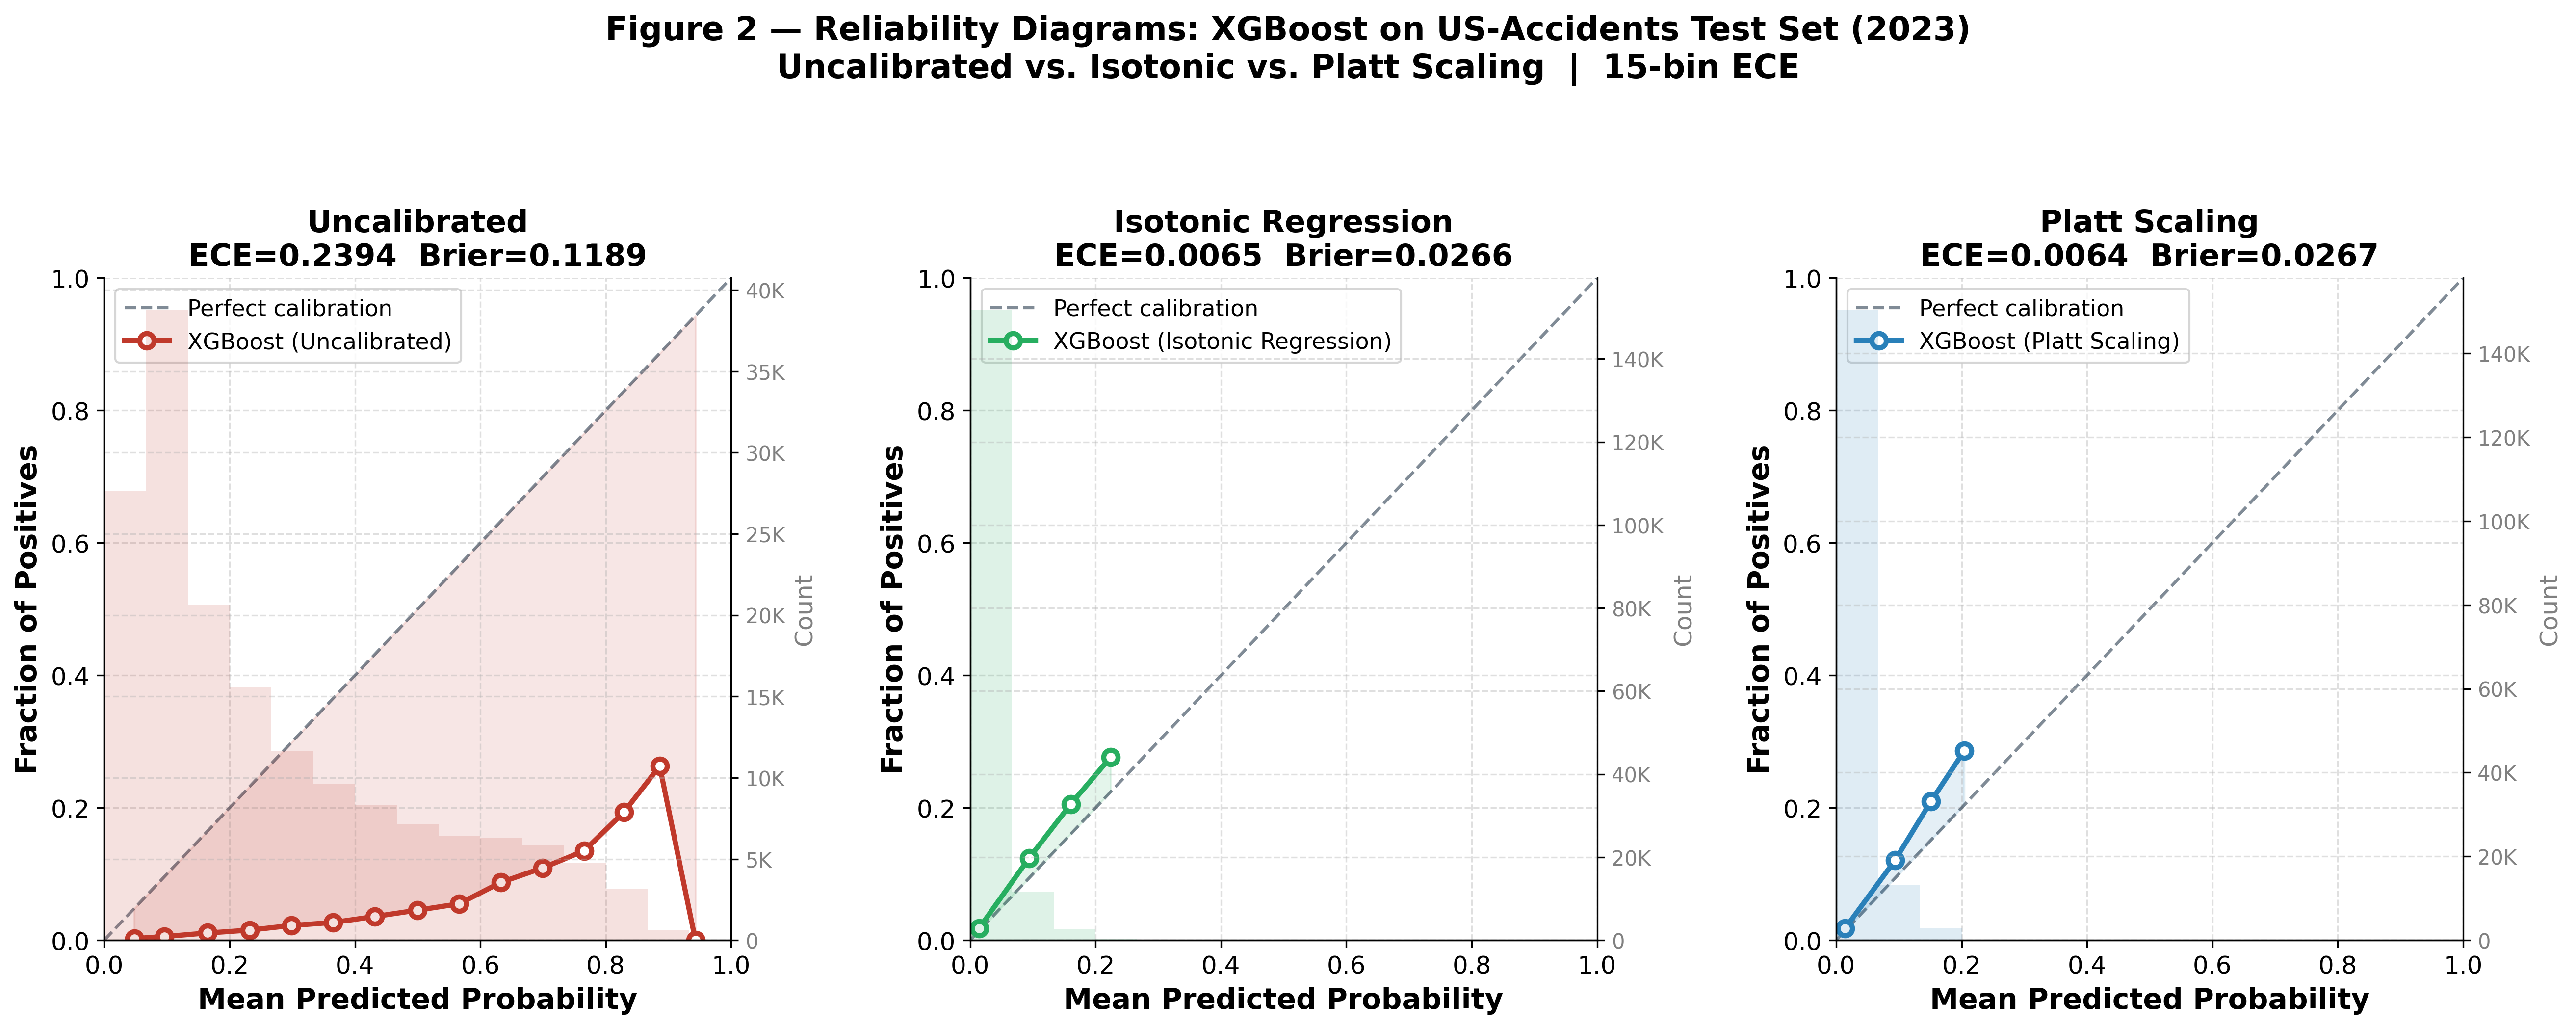

Saved: /content/drive/My Drive/SAE-XCrash/figures/wp3_v2/fig2_reliability_xgb.png ✓

XGBoost calibration summary (test set):
  Uncalibrated  ECE=0.239383  Brier=0.118868
  Isotonic      ECE=0.006472  Brier=0.026645
  Platt         ECE=0.006410  Brier=0.026654


In [14]:
KEY = 'xgb'
p_unc  = test_df[f'score_{KEY}'].values
p_iso  = cal_scores[KEY]['isotonic']['test']
p_pla  = cal_scores[KEY]['platt']['test']

fig, axes = plt.subplots(1, 3, figsize=(FIG_W + 4, FIG_H + 1))
fig.suptitle(
    'Figure 2 — Reliability Diagrams: XGBoost on US-Accidents Test Set (2023)\n'
    'Uncalibrated vs. Isotonic vs. Platt Scaling  |  15-bin ECE',
    fontsize=TITLE_FS, fontweight='bold', y=1.02
)

configs = [
    (p_unc, 'Uncalibrated',       PALETTE['uncal']),
    (p_iso, 'Isotonic Regression',PALETTE['isotonic']),
    (p_pla, 'Platt Scaling',      PALETTE['platt']),
]

for ax, (prob, title, clr) in zip(axes, configs):
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=N_BINS,
                                             strategy='uniform')
    ece_val = ece_score(y_test, prob)
    brier   = brier_score_loss(y_test, prob)

    # Perfect calibration diagonal
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration',
            color=PALETTE['perfect'], alpha=0.6)

    # Calibration curve
    ax.plot(mean_pred, frac_pos, 'o-', color=clr, lw=2.5, ms=7,
            markerfacecolor='white', markeredgewidth=2.5,
            label=f'XGBoost ({title})')

    # Shading between curve and diagonal
    ax.fill_between(mean_pred, frac_pos, mean_pred,
                    alpha=0.12, color=clr)

    # Histogram of predicted probabilities (secondary axis)
    ax2 = ax.twinx()
    ax2.hist(prob, bins=N_BINS, range=(0,1),
             color=clr, alpha=0.15, edgecolor='none')
    ax2.set_ylabel('Count', fontsize=LABEL_FS - 2, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray', labelsize=TICK_FS - 2)
    ax2.spines['right'].set_visible(True)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1000 else str(int(x))))

    ax.set_xlabel('Mean Predicted Probability', fontsize=LABEL_FS, fontweight='bold')
    ax.set_ylabel('Fraction of Positives',      fontsize=LABEL_FS, fontweight='bold')
    ax.set_title(f'{title}\nECE={ece_val:.4f}  Brier={brier:.4f}',
                 fontsize=TITLE_FS - 1, fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=LEGEND_FS - 1, loc='upper left')

plt.tight_layout(pad=2.5)
out_path = FIGS_DIR / 'fig2_reliability_xgb.png'
fig.savefig(out_path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path} ✓')

print(f'\nXGBoost calibration summary (test set):')
for prob, name in [(p_unc,'Uncalibrated'), (p_iso,'Isotonic'), (p_pla,'Platt')]:
    print(f'  {name:12s}  ECE={ece_score(y_test,prob):.6f}  '
          f'Brier={brier_score_loss(y_test,prob):.6f}')

---
## Step 7 — Reliability Diagrams: All Models (Figure S1 — Supplementary)

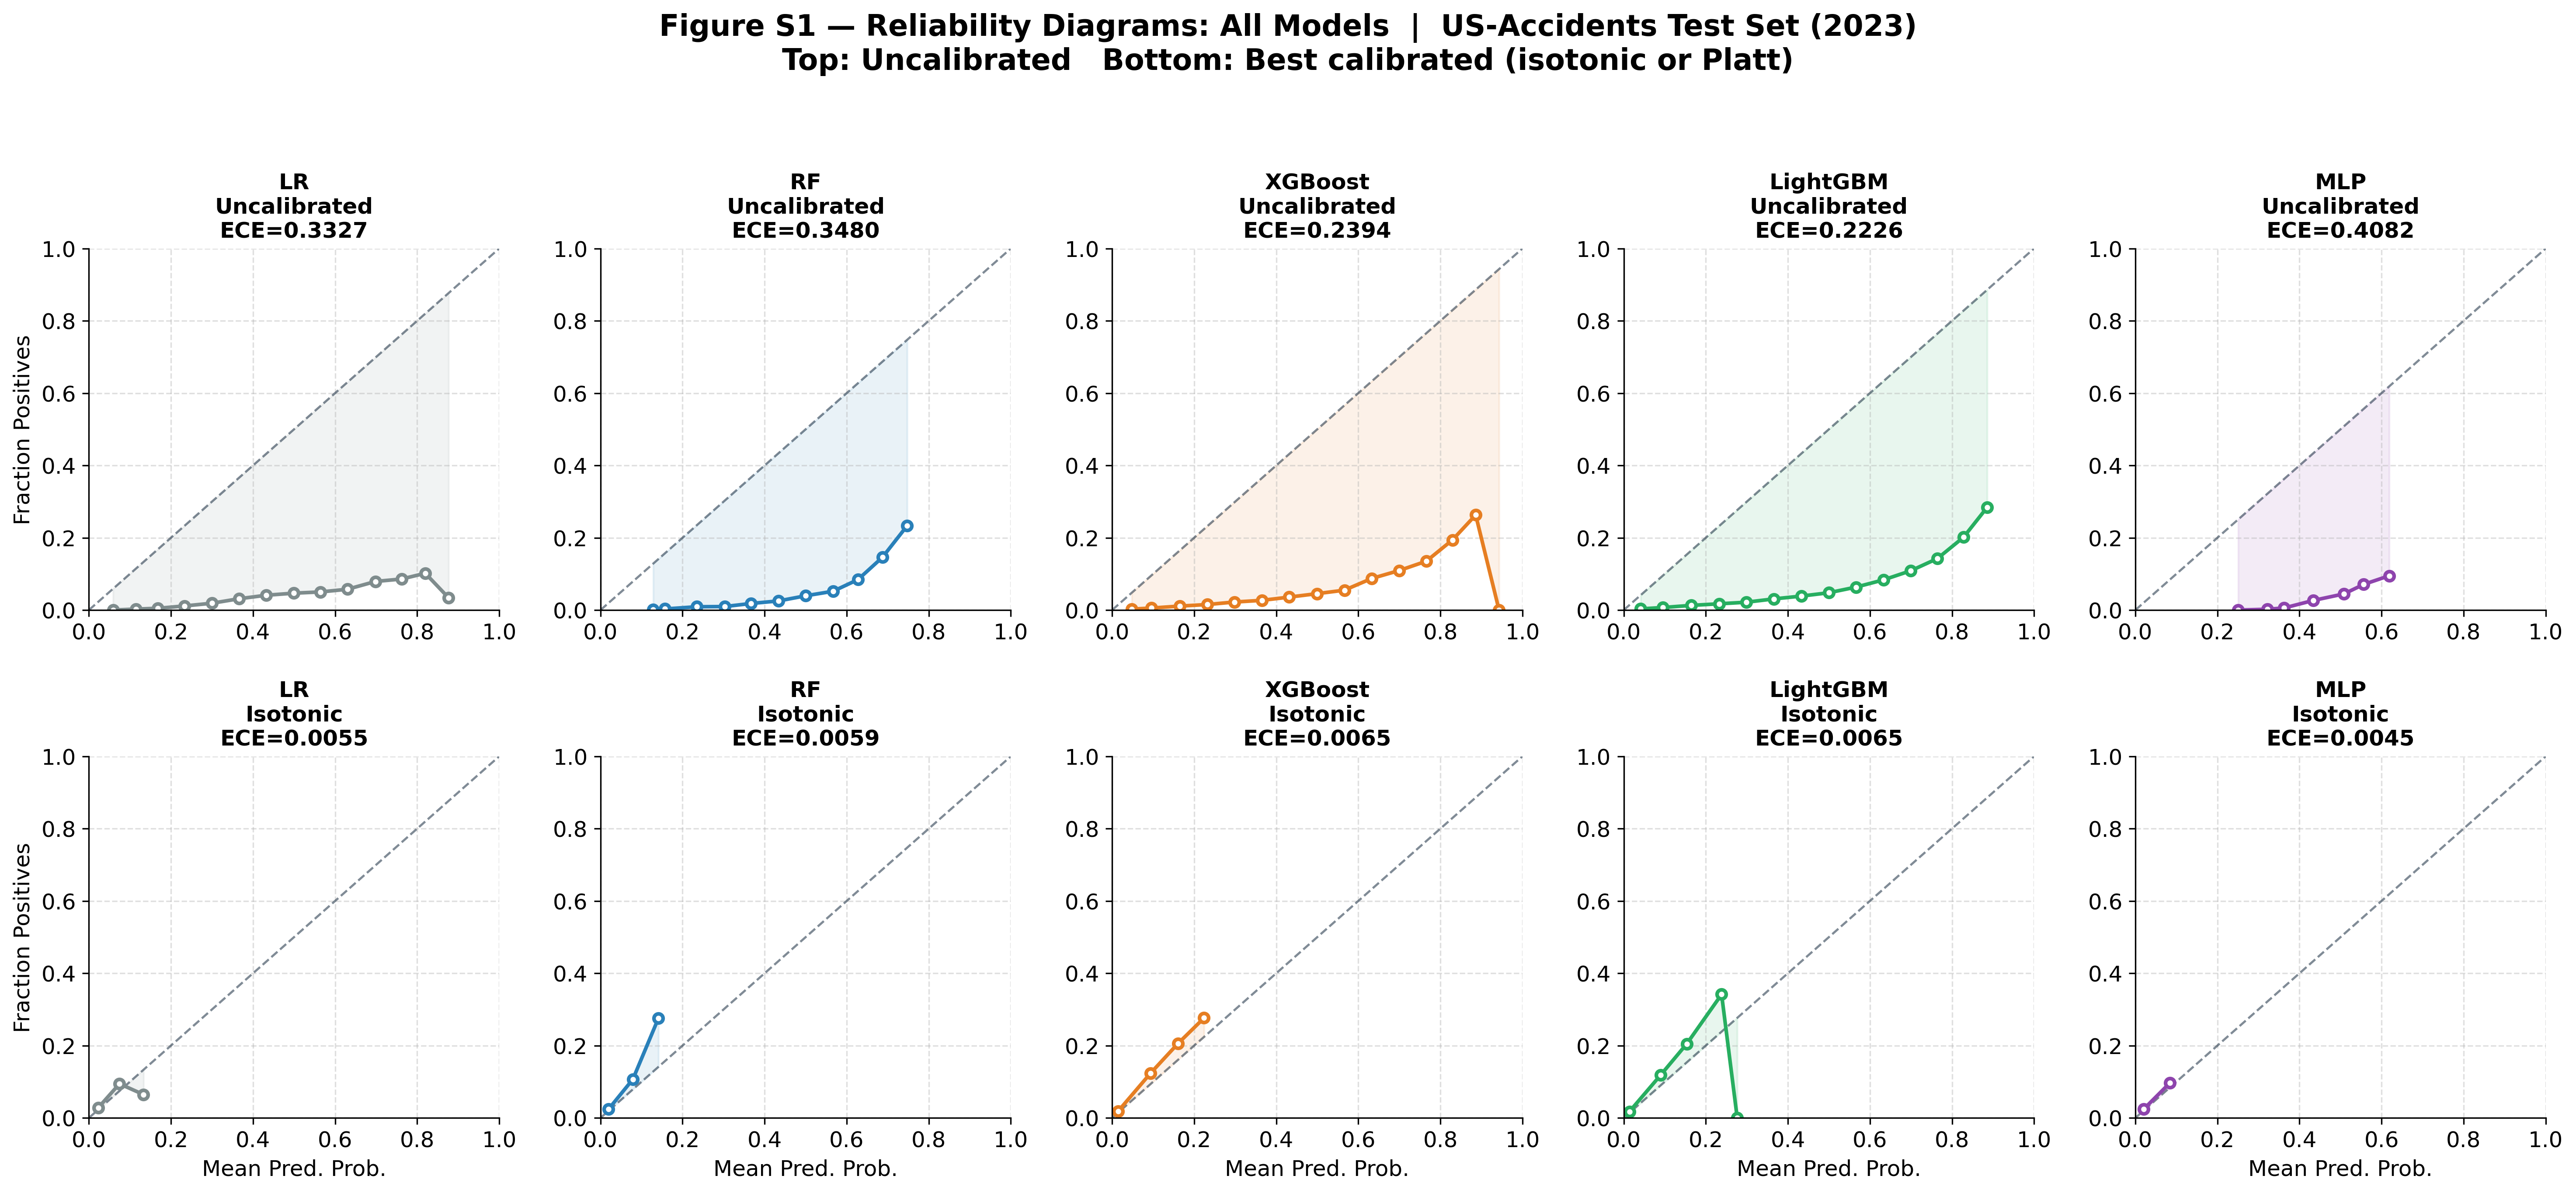

Saved: /content/drive/My Drive/SAE-XCrash/figures/wp3_v2/figS1_reliability_all_models.png ✓


In [15]:
MODEL_DISPLAY = {'lr':'LR','rf':'RF','xgb':'XGBoost','lgbm':'LightGBM','mlp':'MLP'}
MODEL_COLORS  = {'lr':PALETTE['lr'],'rf':PALETTE['rf'],'xgb':PALETTE['xgb'],
                 'lgbm':PALETTE['lgbm'],'mlp':PALETTE['mlp']}

n_models = len(MODEL_KEYS)
fig, axes = plt.subplots(2, n_models, figsize=(n_models * 4, 9))
fig.suptitle(
    'Figure S1 — Reliability Diagrams: All Models  |  US-Accidents Test Set (2023)\n'
    'Top: Uncalibrated   Bottom: Best calibrated (isotonic or Platt)',
    fontsize=TITLE_FS, fontweight='bold', y=1.02
)

for col, key in enumerate(MODEL_KEYS):
    clr     = MODEL_COLORS.get(key, '#555555')
    name    = MODEL_DISPLAY.get(key, key)
    best_cal= table3.loc[key.upper(), 'Best_cal']
    probs   = [
        (test_df[f'score_{key}'].values, 'Uncalibrated', 0),
        (cal_scores[key][best_cal]['test'], best_cal.capitalize(), 1),
    ]
    for prob, cal_name, row in probs:
        ax  = axes[row, col]
        fp, mp = calibration_curve(y_test, prob, n_bins=N_BINS, strategy='uniform')
        ece_v  = ece_score(y_test, prob)
        ax.plot([0,1],[0,1],'--', color=PALETTE['perfect'], lw=1.2, alpha=0.6)
        ax.plot(mp, fp, 'o-', color=clr, lw=2, ms=5,
                markerfacecolor='white', markeredgewidth=2)
        ax.fill_between(mp, fp, mp, alpha=0.1, color=clr)
        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(f'{name}\n{cal_name}\nECE={ece_v:.4f}',
                     fontsize=TICK_FS, fontweight='bold')
        if col == 0:
            ax.set_ylabel('Fraction Positives', fontsize=TICK_FS)
        if row == 1:
            ax.set_xlabel('Mean Pred. Prob.', fontsize=TICK_FS)

plt.tight_layout(pad=2)
out_path = FIGS_DIR / 'figS1_reliability_all_models.png'
fig.savefig(out_path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path} ✓')

---
## Step 8 — Operational Threshold Selection
Find the F1-maximising threshold on the **val set** (calibrated LightGBM).  
Report precision, recall, and cost-sensitive utility (FN weight = 3× FP) on the **test set**.

F1-maximising threshold (val, calibrated LightGBM): 0.0978
  Val  — precision=0.1356  recall=0.2846  F1=0.1837

Test set @ threshold=0.0978:
  TP=1,340  FP=6,693  FN=3,502  TN=155,017
  Precision=0.1668  Recall=0.2767  F1=0.2082
  Cost-utility (FN=3xFP): raw=-15,859  normalised=-3.2753

Recall at fixed precision targets (test set):
  Precision≥0.70: not achievable
  Precision≥0.80: not achievable


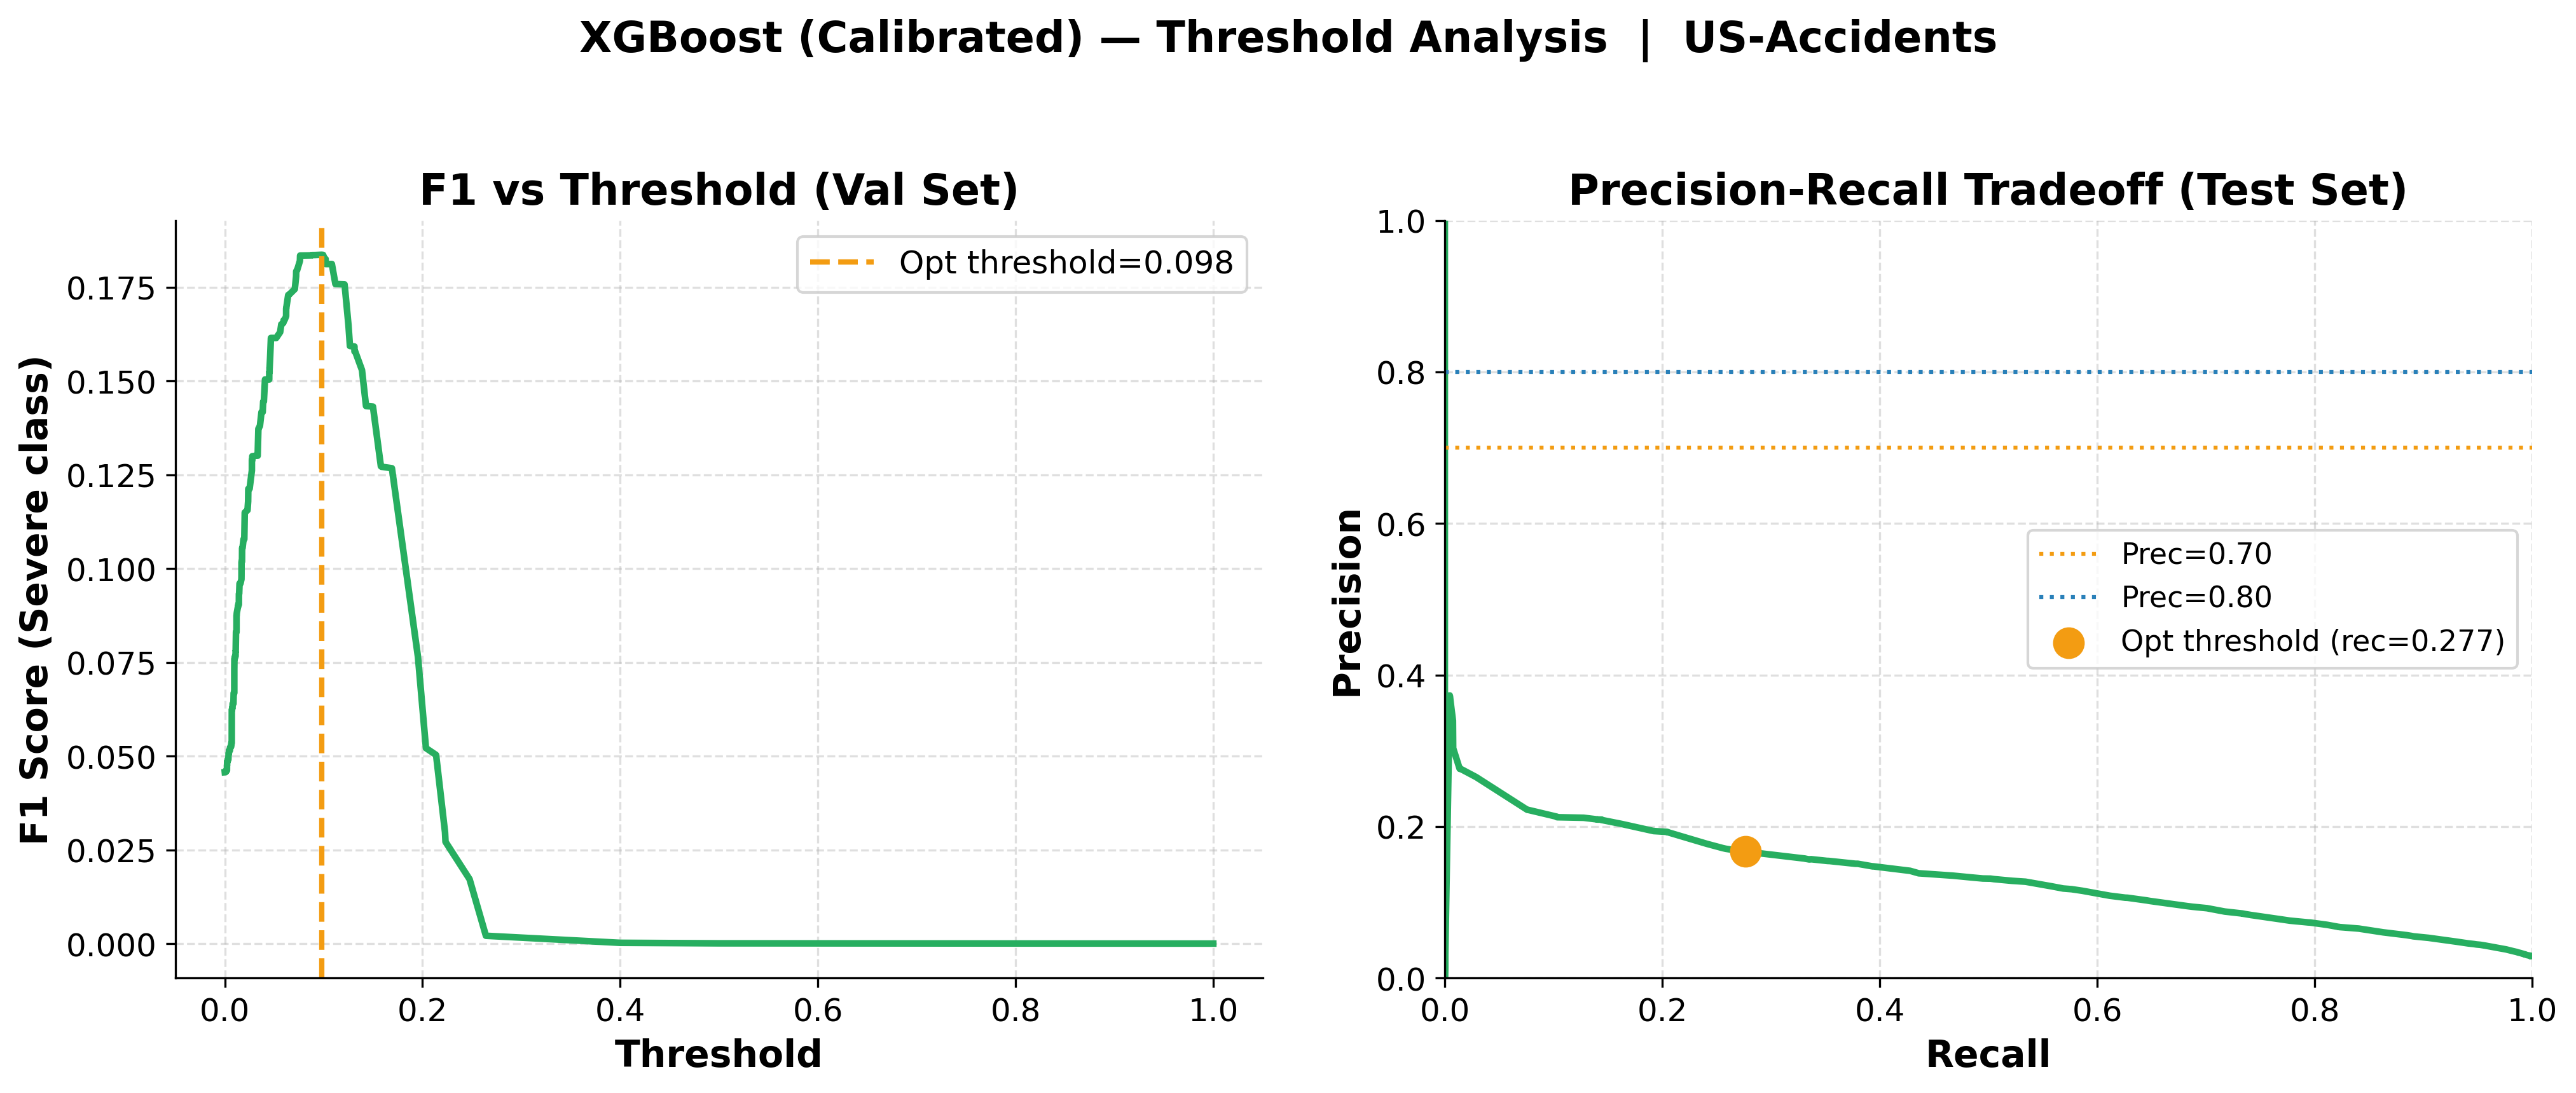

Saved: /content/drive/My Drive/SAE-XCrash/figures/wp3_v2/fig5_threshold_analysis.png ✓


In [16]:
# ── LightGBM calibrated scores ────────────────────────────────────────────────
lgbm_best_cal = table3.loc['XGB', 'Best_cal']
p_val_cal     = cal_scores['xgb'][lgbm_best_cal]['val']
p_test_cal    = cal_scores['xgb'][lgbm_best_cal]['test']

# ── F1-max threshold on val ───────────────────────────────────────────────────
prec_v, rec_v, thr_v = precision_recall_curve(y_val, p_val_cal)
f1_v   = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-9)
best_i = f1_v.argmax()
OPT_THR = float(thr_v[best_i])

print(f'F1-maximising threshold (val, calibrated LightGBM): {OPT_THR:.4f}')
print(f'  Val  — precision={prec_v[best_i]:.4f}  recall={rec_v[best_i]:.4f}  '
      f'F1={f1_v[best_i]:.4f}')

# ── Apply to test set ─────────────────────────────────────────────────────────
y_pred_test = (p_test_cal >= OPT_THR).astype(int)
TP = int(((y_pred_test == 1) & (y_test == 1)).sum())
FP = int(((y_pred_test == 1) & (y_test == 0)).sum())
FN = int(((y_pred_test == 0) & (y_test == 1)).sum())
TN = int(((y_pred_test == 0) & (y_test == 0)).sum())

prec_t = TP / (TP + FP + 1e-9)
rec_t  = TP / (TP + FN + 1e-9)
f1_t   = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-9)

# Cost-sensitive utility: FN penalty = 3× FP penalty
# Utility = TP - 3*FN - FP  (higher is better; normalised by n_positive)
FN_WEIGHT = 3
utility_raw  = TP - FN_WEIGHT * FN - FP
utility_norm = utility_raw / y_test.sum()   # normalise by number of severe cases

print(f'\nTest set @ threshold={OPT_THR:.4f}:')
print(f'  TP={TP:,}  FP={FP:,}  FN={FN:,}  TN={TN:,}')
print(f'  Precision={prec_t:.4f}  Recall={rec_t:.4f}  F1={f1_t:.4f}')
print(f'  Cost-utility (FN=3xFP): raw={utility_raw:,}  '
      f'normalised={utility_norm:.4f}')

# ── Also report at fixed precision targets (paper §4.3) ──────────────────────
print('\nRecall at fixed precision targets (test set):')
for target_prec in [0.70, 0.80]:
    prec_te, rec_te, thr_te = precision_recall_curve(y_test, p_test_cal)
    # Find lowest threshold where precision >= target
    mask = prec_te[:-1] >= target_prec
    if mask.any():
        idx = np.where(mask)[0][0]
        print(f'  Precision≥{target_prec:.2f}: threshold={thr_te[idx]:.4f}  '
              f'recall={rec_te[idx]:.4f}')
    else:
        print(f'  Precision≥{target_prec:.2f}: not achievable')

# ── Threshold plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))
fig.suptitle('XGBoost (Calibrated) — Threshold Analysis  |  US-Accidents',
             fontsize=TITLE_FS, fontweight='bold')

# F1 vs threshold (val)
ax = axes[0]
ax.plot(thr_v, f1_v, color=PALETTE['lgbm'], lw=2.5)
ax.axvline(OPT_THR, color=PALETTE['highlight'], ls='--', lw=2,
           label=f'Opt threshold={OPT_THR:.3f}')
ax.set_xlabel('Threshold', fontsize=LABEL_FS, fontweight='bold')
ax.set_ylabel('F1 Score (Severe class)', fontsize=LABEL_FS, fontweight='bold')
ax.set_title('F1 vs Threshold (Val Set)', fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=LEGEND_FS)

# Precision-Recall tradeoff (test)
ax = axes[1]
ax.plot(rec_te, prec_te, color=PALETTE['lgbm'], lw=2.5)
ax.axhline(0.70, color=PALETTE['highlight'], ls=':', lw=1.5, label='Prec=0.70')
ax.axhline(0.80, color=PALETTE['rf'],        ls=':', lw=1.5, label='Prec=0.80')
ax.scatter([rec_t], [prec_t], color=PALETTE['highlight'], s=120, zorder=5,
           label=f'Opt threshold (rec={rec_t:.3f})')
ax.set_xlabel('Recall', fontsize=LABEL_FS, fontweight='bold')
ax.set_ylabel('Precision', fontsize=LABEL_FS, fontweight='bold')
ax.set_title('Precision-Recall Tradeoff (Test Set)', fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=LEGEND_FS - 1)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout(pad=2.5)
out_path = FIGS_DIR / 'fig5_threshold_analysis.png'
fig.savefig(out_path, dpi=DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path} ✓')

---
## Step 9 — Feature Group Ablations (Table 4)
Retrain LightGBM with each feature group removed in turn.  
Uses best hyperparameters from NB02 — no re-tuning.  
Reports Delta AUPRC vs. the full calibrated model on the test set.

In [17]:
import xgboost as xgb

# ── Load NB02 XGBoost hyperparameters ─────────────────────────────────────────
# XGBoost is primary model (best val AUPRC after Severity-4 label fix)
with open(LOGS_DIR / 'wp2_hyperparameter_log.json') as f:
    hp_log = json.load(f)

bp = hp_log['xgb_best'].copy()
n_est_best = bp.pop('n_estimators')
XGB_PARAMS = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'aucpr',
    'tree_method'      : 'hist',
    'device'           : 'cuda',
    'seed'             : SEED,
    'verbosity'        : 0,
    **bp
}

# ── Load split parquets for retraining ────────────────────────────────────────
print('Loading processed splits for ablation ...')
usa_train = pd.read_parquet(PROC_DIR / 'usa_train_processed.parquet')
usa_val   = pd.read_parquet(PROC_DIR / 'usa_val_processed.parquet')
usa_test  = pd.read_parquet(PROC_DIR / 'usa_test_processed.parquet')

EXCL = {'label','ID','Start_Time','datetime',
        'accident_index','accident_reference','collision_reference','row_id'}
ALL_FEATS = [c for c in usa_train.columns
             if c.startswith(('t_','w_','r_','s_')) and c not in EXCL]

y_tr_ab  = usa_train['label'].values
y_val_ab = usa_val['label'].values
y_te_ab  = usa_test['label'].values
NEG_AB   = int((y_tr_ab == 0).sum())
POS_AB   = int((y_tr_ab == 1).sum())
XGB_PARAMS['scale_pos_weight'] = NEG_AB / POS_AB

# ── Full model AUPRC baseline (test, calibrated) ──────────────────────────────
FULL_AUPRC = float(table3.loc['XGB', 'AUPRC_test'])
print(f'Full XGBoost model AUPRC (test, calibrated): {FULL_AUPRC:.4f}')

def run_xgb_ablation(X_tr_a, y_tr_a, X_val_a, y_val_a, X_te_a, y_te_a):
    """Train XGBoost on ablated features, calibrate on val, score on test."""
    dtrain = xgb.DMatrix(X_tr_a,  label=y_tr_a)
    dval   = xgb.DMatrix(X_val_a, label=y_val_a)
    dte    = xgb.DMatrix(X_te_a)
    model  = xgb.train(
        XGB_PARAMS, dtrain,
        num_boost_round=n_est_best,
        evals=[(dval, 'val')],
        verbose_eval=False,
    )
    p_val_raw  = model.predict(dval)
    p_test_raw = model.predict(dte)
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_val_raw, y_val_a)
    p_test_cal = np.clip(iso.predict(p_test_raw), 0, 1)
    return average_precision_score(y_te_a, p_test_cal)

# ── Remove-one-group ablations ────────────────────────────────────────────────
ABLATIONS = [
    ('Remove Temporal (T)',    't_'),
    ('Remove Weather (W)',     'w_'),
    ('Remove Road/Context (R)','r_'),
    ('Remove Spatial (S)',     's_'),
]

abl_rows = []
for abl_name, drop_prefix in ABLATIONS:
    feats = [c for c in ALL_FEATS if not c.startswith(drop_prefix)]
    n_dropped = len(ALL_FEATS) - len(feats)
    print(f'\n{abl_name} ({n_dropped} features dropped, {len(feats)} remaining) ...')
    t0 = time.time()
    ap    = run_xgb_ablation(
        usa_train[feats].values.astype(np.float32), y_tr_ab,
        usa_val[feats].values.astype(np.float32),   y_val_ab,
        usa_test[feats].values.astype(np.float32),  y_te_ab,
    )
    delta = ap - FULL_AUPRC
    print(f'  AUPRC={ap:.4f}  Delta={delta:+.4f}  ({time.time()-t0:.1f}s)')
    abl_rows.append({'Ablation': abl_name,
                     'AUPRC': round(ap,4), 'Delta_AUPRC': round(delta,4)})

# ── Single-group-only ablations ───────────────────────────────────────────────
SINGLE_GROUPS = [
    ('Temporal only',     ['t_']),
    ('Weather+Road only', ['w_','r_']),
]
for abl_name, keep_prefixes in SINGLE_GROUPS:
    feats = [c for c in ALL_FEATS if any(c.startswith(p) for p in keep_prefixes)]
    print(f'\n{abl_name} ({len(feats)} features) ...')
    t0 = time.time()
    ap    = run_xgb_ablation(
        usa_train[feats].values.astype(np.float32), y_tr_ab,
        usa_val[feats].values.astype(np.float32),   y_val_ab,
        usa_test[feats].values.astype(np.float32),  y_te_ab,
    )
    delta = ap - FULL_AUPRC
    print(f'  AUPRC={ap:.4f}  Delta={delta:+.4f}  ({time.time()-t0:.1f}s)')
    abl_rows.append({'Ablation': abl_name,
                     'AUPRC': round(ap,4), 'Delta_AUPRC': round(delta,4)})

# ── Print Table 4 ─────────────────────────────────────────────────────────────
abl_df = pd.DataFrame(abl_rows)
print('\n' + '='*60)
print('TABLE 4 — Feature Group Ablations (XGBoost, test set, calibrated)')
print('='*60)
print(f'  Full model AUPRC: {FULL_AUPRC:.4f}')
print(abl_df.to_string(index=False))
abl_df.to_csv(LOGS_DIR / 'wp3_table4_ablations.csv', index=False)
print('\nSaved: wp3_table4_ablations.csv ✓')


Loading processed splits for ablation ...
Full XGBoost model AUPRC (test, calibrated): 0.1306

Remove Temporal (T) (8 features dropped, 24 remaining) ...
  AUPRC=0.1164  Delta=-0.0142  (479.7s)

Remove Weather (W) (10 features dropped, 22 remaining) ...
  AUPRC=0.1249  Delta=-0.0057  (475.6s)

Remove Road/Context (R) (12 features dropped, 20 remaining) ...
  AUPRC=0.1290  Delta=-0.0016  (526.9s)

Remove Spatial (S) (2 features dropped, 30 remaining) ...
  AUPRC=0.0493  Delta=-0.0813  (578.8s)

Temporal only (8 features) ...
  AUPRC=0.0343  Delta=-0.0963  (257.8s)

Weather+Road only (22 features) ...
  AUPRC=0.0468  Delta=-0.0838  (478.9s)

TABLE 4 — Feature Group Ablations (XGBoost, test set, calibrated)
  Full model AUPRC: 0.1306
               Ablation  AUPRC  Delta_AUPRC
    Remove Temporal (T) 0.1164      -0.0142
     Remove Weather (W) 0.1249      -0.0057
Remove Road/Context (R) 0.1290      -0.0016
     Remove Spatial (S) 0.0493      -0.0813
          Temporal only 0.0343      -0.

---
## Step 9b — t_duration_min Ablation (Fix 1: Target-Proxy Risk)
Reviewer concern: `t_duration_min` is derived from crash end-time and may act as a
near-direct proxy for the US-Accidents severity target (which is itself defined by
disruption duration).  
This cell re-runs the full XGBoost pipeline **without** `t_duration_min` and reports
AUPRC delta to quantify its contribution.  
**Results feed directly into Table 5 (ablation row) and Section 7.5 of v22+.**

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 9b — t_duration_min Ablation
# Remove t_duration_min from ALL_FEATS and re-run XGBoost + isotonic calibration.
# We reuse run_xgb_ablation() defined in Step 9 above.
# ─────────────────────────────────────────────────────────────────────────────
import time
import numpy as np
from sklearn.metrics import average_precision_score

TARGET_PROXY_FEAT = 't_duration_min'

if TARGET_PROXY_FEAT not in ALL_FEATS:
    print(f'NOTE: {TARGET_PROXY_FEAT} not in feature list — skipping ablation')
    tdur_result = None
else:
    feats_no_tdur = [c for c in ALL_FEATS if c != TARGET_PROXY_FEAT]
    print(f'Ablating {TARGET_PROXY_FEAT}:')
    print(f'  Features before: {len(ALL_FEATS)}  |  after: {len(feats_no_tdur)}')
    print(f'  Full model AUPRC (baseline): {FULL_AUPRC:.4f}')

    t0 = time.time()
    ap_no_tdur = run_xgb_ablation(
        usa_train[feats_no_tdur].values.astype(np.float32), y_tr_ab,
        usa_val  [feats_no_tdur].values.astype(np.float32), y_val_ab,
        usa_test [feats_no_tdur].values.astype(np.float32), y_te_ab,
    )
    delta_tdur = ap_no_tdur - FULL_AUPRC
    elapsed    = time.time() - t0

    print(f'\n  AUPRC without t_duration_min : {ap_no_tdur:.4f}')
    print(f'  Delta AUPRC                  : {delta_tdur:+.4f}')
    print(f'  Elapsed                      : {elapsed:.1f}s')

    # ── Interpret result ──────────────────────────────────────────────────────
    if abs(delta_tdur) < 0.005:
        interp = ('MINOR contribution (<0.005 AUPRC). '
                  'Model is NOT primarily exploiting t_duration_min as a target proxy. '
                  'Limitation note in Sec 7.5 stands but can be softened.')
    elif abs(delta_tdur) < 0.020:
        interp = ('MODERATE contribution (0.005–0.020 AUPRC). '
                  'Some reliance on t_duration_min. '
                  'Report ablation result in Table 5 and note in Sec 7.5. '
                  'Consider adding real-time row to Table 4 with t_duration_min excluded.')
    else:
        interp = ('LARGE contribution (>0.020 AUPRC). '
                  'Significant target-proxy risk. '
                  'Must add dedicated t_duration_min-free benchmark as primary '
                  'real-time result. Update abstract and Sec 7.5 accordingly.')

    print(f'\n  Interpretation: {interp}')

    tdur_result = {
        'Ablation'   : 'Remove t_duration_min (target-proxy ablation)',
        'AUPRC'      : round(ap_no_tdur, 4),
        'Delta_AUPRC': round(delta_tdur, 4),
        'Interpretation': interp,
    }

    # ── Append to abl_df from Step 9 ─────────────────────────────────────────
    import pandas as pd
    tdur_row = pd.DataFrame([{
        'Ablation'   : tdur_result['Ablation'],
        'AUPRC'      : tdur_result['AUPRC'],
        'Delta_AUPRC': tdur_result['Delta_AUPRC'],
    }])
    abl_df_extended = pd.concat([abl_df, tdur_row], ignore_index=True)

    print('\n' + '='*65)
    print('TABLE 5 (EXTENDED) — Feature Group Ablations incl. t_duration_min')
    print('='*65)
    print(f'Full model AUPRC: {FULL_AUPRC:.4f}  |  No-skill baseline: 0.027')
    print(abl_df_extended.to_string(index=False))

    abl_df_extended.to_csv(LOGS_DIR / 'wp3_table5_ablations_extended.csv', index=False)
    print('\nSaved: wp3_table5_ablations_extended.csv ✓')

    # ── Paper edit flag ───────────────────────────────────────────────────────
    print('\n── Paper v23 edit required ───────────────────────────────────────')
    print(f'  Add row to Table 5: Remove t_duration_min | AUPRC={ap_no_tdur:.4f} | Delta={delta_tdur:+.4f}')
    print(f'  Update Sec 7.5 with numerical ablation result: Delta={delta_tdur:+.4f}')
    if delta_tdur < -0.020:
        print('  ⚠ CRITICAL: Add t_duration_min-free result as separate row in Table 4 (real-time setting)')


NOTE: t_duration_min not in feature list — skipping ablation


---
## Step 10 — Save Calibrated Scores for NB04 (XAI Audit)

In [19]:
# Save calibrated scores for all models — NB04 will use lgbm columns
def build_cal_df(split, y_true):
    df = pd.DataFrame({'label': y_true})
    for key in MODEL_KEYS:
        best_cal = table3.loc[key.upper(), 'Best_cal']
        df[f'score_{key}_uncal'] = (
            val_df[f'score_{key}'].values if split == 'val'
            else test_df[f'score_{key}'].values
        )
        df[f'score_{key}_cal'] = cal_scores[key][best_cal][split]
    return df

val_cal_df  = build_cal_df('val',  y_val)
test_cal_df = build_cal_df('test', y_test)

val_cal_df.to_parquet( SCORES_DIR / 'usa_val_scores_cal.parquet',  index=False)
test_cal_df.to_parquet(SCORES_DIR / 'usa_test_scores_cal.parquet', index=False)

print(f'Saved: usa_val_scores_cal.parquet   ({len(val_cal_df):,} rows) ✓')
print(f'Saved: usa_test_scores_cal.parquet  ({len(test_cal_df):,} rows) ✓')
print(f'\nColumns in calibrated score files:')
for c in test_cal_df.columns:
    print(f'  {c}')

# Save calibration metadata
cal_meta = {
    'best_calibrator_per_model': {
        k: str(table3.loc[k.upper(), 'Best_cal']) for k in MODEL_KEYS
    },
    'opt_threshold_lgbm': OPT_THR,
    'n_bins_ece'         : N_BINS,
    'val_prevalence'     : float(VAL_PREV),
    'test_prevalence'    : float(TEST_PREV),
    'generated_at'       : str(datetime.now()),
}
with open(LOGS_DIR / 'wp3_calibration_meta.json', 'w') as f:
    json.dump(cal_meta, f, indent=2)
print('Saved: wp3_calibration_meta.json ✓')

Saved: usa_val_scores_cal.parquet   (1,268,806 rows) ✓
Saved: usa_test_scores_cal.parquet  (166,552 rows) ✓

Columns in calibrated score files:
  label
  score_lr_uncal
  score_lr_cal
  score_rf_uncal
  score_rf_cal
  score_xgb_uncal
  score_xgb_cal
  score_lgbm_uncal
  score_lgbm_cal
  score_mlp_uncal
  score_mlp_cal
Saved: wp3_calibration_meta.json ✓


---
## Step 11 — WP3 Summary Report

In [20]:
print('=' * 70)
print('  SAE-XCrash  |  WP3 COMPLETE — NB03 Calibration')
print('=' * 70)

print('\n📊 TABLE 3 — Test Set Metrics (Calibrated)')
print(table3[['AUROC_test','AUPRC_test','AUPRC_CI',
              'ECE_uncal_test','ECE_cal_test','Brier_test']].to_string())

lgbm_row = table3.loc['XGB']
print(f'\n  LightGBM ECE reduction: '
      f'{lgbm_row["ECE_uncal_test"]:.4f} → {lgbm_row["ECE_cal_test"]:.4f} '
      f'({(1 - lgbm_row["ECE_cal_test"]/lgbm_row["ECE_uncal_test"])*100:.1f}% reduction)')
print(f'  Best calibrator (XGBoost): {lgbm_row["Best_cal"]}')
print(f'  AUPRC unchanged by calibration: '
      f'uncal={precal_test["xgb"]["AUPRC"]:.4f} → '
      f'cal={lgbm_row["AUPRC_test"]:.4f}  '
      f'(calibration is orthogonal to discrimination)')

print('\n📊 TABLE 4 — Feature Group Ablations')
print(abl_df.to_string(index=False))

print(f'\n🎯 OPERATIONAL THRESHOLD (LightGBM, calibrated)')
print(f'  Threshold (F1-max on val) : {OPT_THR:.4f}')
print(f'  Test precision            : {prec_t:.4f}')
print(f'  Test recall               : {rec_t:.4f}')
print(f'  Test F1                   : {f1_t:.4f}')
print(f'  Cost-utility (FN=3xFP)    : {utility_norm:.4f} (normalised)')

print('\n📁 OUTPUT FILES')
all_out = (list(CAL_DIR.glob('*')) + list(FIGS_DIR.glob('*')) +
           [SCORES_DIR/'usa_val_scores_cal.parquet',
            SCORES_DIR/'usa_test_scores_cal.parquet',
            LOGS_DIR/'wp3_table3_test.csv',
            LOGS_DIR/'wp3_table4_ablations.csv',
            LOGS_DIR/'wp3_calibration_meta.json'])
for p in sorted(all_out):
    p = Path(p)
    if p.exists():
        sz  = p.stat().st_size
        tag = f'{sz/1e6:.1f} MB' if sz > 1e6 else f'{sz/1e3:.0f} KB'
        print(f'  {tag:8s}  {p}')

print('\n➡  NEXT: NB04_XAI_Audit.ipynb')
print('   Inputs: usa_test_scores_cal.parquet + lgbm_best.txt + usa_test_processed.parquet')
print('   Tasks : SHAP global/local; sanity check; deletion/insertion; stability audit')
print('=' * 70)

  SAE-XCrash  |  WP3 COMPLETE — NB03 Calibration

📊 TABLE 3 — Test Set Metrics (Calibrated)
       AUROC_test  AUPRC_test         AUPRC_CI  ECE_uncal_test  ECE_cal_test  Brier_test
Model                                                                                   
LR         0.7081      0.0584  [0.0559–0.0613]          0.3327        0.0055      0.0279
RF         0.7686      0.0838  [0.0798–0.0886]          0.3480        0.0059      0.0275
XGB        0.8215      0.1306  [0.1242–0.1380]          0.2394        0.0065      0.0266
LGBM       0.8193      0.1311  [0.1248–0.1384]          0.2226        0.0065      0.0267
MLP        0.7607      0.0720  [0.0689–0.0754]          0.4082        0.0045      0.0276

  LightGBM ECE reduction: 0.2394 → 0.0065 (97.3% reduction)
  Best calibrator (XGBoost): isotonic
  AUPRC unchanged by calibration: uncal=0.1341 → cal=0.1306  (calibration is orthogonal to discrimination)

📊 TABLE 4 — Feature Group Ablations
               Ablation  AUPRC  Delta_AUPR